## Objective

In this notebook we calculate MAE and RMSE of 1-step, 2-step, and 3-step ahead IESO forecasting , and compare the results with our final chosen model (GRU) and visualize the forcasting on the test set.

## IESO Benchmark 
in the first stage of this notebook we load master dataset and do preprocessing to  calculate MSE and RMSE of IESO forecasting. 

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error



RESULTS_DIR =Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)

## Helper Functions

In [64]:
# Return the two error metrics used throughout this notebook.
def evaluate(y_ture, y_pred):
    mae = mean_absolute_error(y_ture, y_pred)
    rmse = np.sqrt(mean_squared_error(y_ture, y_pred))
    return mae, rmse

# Split the full test period into equal-sized chunks so we can compare performance
def evaluate_by_chunks(y_true, y_pred, model_name, n_chunks= 4):
    y_true_chunks = np.array_split(np.asarray(y_true), n_chunks)
    y_pred_chunks = np.array_split(np.asarray(y_pred), n_chunks)
    results = []
    # Each chunk is evaluated independently and stored with its chunk index.
    for i,(y_true_chunk, y_pred_chunk) in enumerate(zip(y_true_chunks, y_pred_chunks), start=1):
        mae, rmse = evaluate(y_true_chunk, y_pred_chunk)
        results.append({"model": model_name, "chunk": i, "mae": mae, "rmse": rmse})
    return pd.DataFrame(results)

# Plot the actual HOEP series against one or more forecast series for a selected window.
def plot_predictions(y_true, preds_dict, horizon, start_idx= None, end_idx=None):
    plt.figure(figsize=(12, 5))
    plt.plot(np.asarray(y_true)[start_idx:end_idx], label="Actual", linewidth=2)

    # Overlay each model's prediction for the same time range on top of the actual series.
    for model_name, pred in preds_dict.items():
        plt.plot(np.asarray(pred)[start_idx:end_idx], label=model_name, alpha=0.8)

    plt.title(f"Forecast vs Actual — Horizon {horizon}")
    plt.xlabel("Time Index")
    plt.ylabel("HOEP")
    plt.legend()
    plt.grid(True)
    plt.show()

## Load datasets( for IESO benchmark and GRU model)

In [ ]:
# Load the master dataset that already contains actual HOEP values and IESO pre-dispatch inputs.
master_dataset = pd.read_parquet("../data/processed/master_dataset.parquet")

# Fill missing IESO pre-dispatch values so later shifting and evaluation do not break on NaNs.
for h in [1,2,3]:
    col_name = f"hour_{h}_predispatch"
    mean_value = master_dataset[col_name].mean()
    master_dataset[col_name]=master_dataset[col_name].fillna(mean_value)

In [66]:
# Align each IESO pre-dispatch forecast with the hour it is trying to predict.
for h in [1,2,3]:
    master_dataset[f"pred_h{h}"]= master_dataset[f"hour_{h}_predispatch"].shift(h)

In [67]:
master_dataset.tail(30)

,date,hour,market_key,hoep,hour_1_predispatch,hour_2_predispatch,hour_3_predispatch,market_demand,ontario_demand,nuclear,...,total_output,month,day_of_week,year,is_weekend,season,time_index,pred_h1,pred_h2,pred_h3
20394,2025-04-29 04:00:00,19,2025-04-29_H19,5.82,14.37,14.37,5.83,18952.0,15928.0,9110.0,...,18998,4,3,2025,0,1,20394,14.32,5.62,4.94
20395,2025-04-29 04:00:00,20,2025-04-29_H20,5.56,14.35,14.37,14.40,18741.0,15806.0,9105.0,...,18793,4,3,2025,0,1,20395,14.37,5.62,5.04
20396,2025-04-29 04:00:00,21,2025-04-29_H21,5.03,14.31,14.34,14.37,18547.0,15524.0,9104.0,...,18632,4,3,2025,0,1,20396,14.35,14.37,4.91
20397,2025-04-29 04:00:00,22,2025-04-29_H22,0.40,5.65,5.92,5.83,17624.0,14701.0,9101.0,...,17692,4,3,2025,0,1,20397,14.31,14.37,5.83
20398,2025-04-29 04:00:00,23,2025-04-29_H23,0.00,0.00,0.00,0.00,16596.0,13780.0,9101.0,...,16628,4,3,2025,0,1,20398,5.65,14.34,14.40
20399,2025-04-29 04:00:00,24,2025-04-29_H24,0.00,0.00,0.00,0.00,16059.0,13106.0,9106.0,...,16059,4,3,2025,0,1,20399,0.00,5.92,14.37
20400,2025-04-30 04:00:00,1,2025-04-30_H01,0.00,0.00,0.00,0.00,15676.0,12721.0,9108.0,...,15547,4,4,2025,0,1,20400,0.00,0.00,5.83
20401,2025-04-30 04:00:00,2,2025-04-30_H02,0.00,0.00,0.00,0.00,15132.0,12550.0,9108.0,...,15028,4,4,2025,0,1,20401,0.00,0.00,0.00
20402,2025-04-30 04:00:00,3,2025-04-30_H03,0.00,0.00,0.00,0.00,15132.0,12561.0,9109.0,...,14935,4,4,2025,0,1,20402,0.00,0.00,0.00
20403,2025-04-30 04:00:00,4,2025-04-30_H04,7.32,5.83,5.69,0.00,15637.0,12713.0,9111.0,...,15535,4,4,2025,0,1,20403,0.00,0.00,0.00


In [68]:
# Use the same test-period cutoff as the modeling notebooks so the benchmark comparison is fair.
start_date = pd.Timestamp("2025-04-01")
master_test_df = master_dataset.loc[master_dataset["date"] >= start_date]
print(f"Test set startd from {master_test_df['market_key'].min()} to {master_test_df['market_key'].max()} \n",f"test set shape is {master_test_df.shape}")

Test set startd from 2025-04-01_H01 to 2025-04-30_H24 
 test set shape is (720, 26)


### IESO Benchmark evaluation

In [69]:
# Evaluate IESO forecasts separately for 1, 2, and 3 hour horizons.
# Each horizon is broken into 4 chunks so we can inspect whether errors stay stable over time.
ieso_weekly_rows =[]
for h in [1,2,3]:
    results_df = evaluate_by_chunks(master_test_df["hoep"], master_test_df[f"pred_h{h}"], model_name="IESO")
    ieso_weekly_rows.append(results_df)
print("Evaluation of IESO's forecasts by week:")
# Combine all horizon-level results into one table for easier comparison.
ieso_weekly_df= pd.concat(ieso_weekly_rows, ignore_index=True)
ieso_weekly_df

Evaluation of IESO's forecasts by week:


,model,chunk,mae,rmse
0,IESO,1,29.272923,61.775582
1,IESO,2,24.287056,54.439371
2,IESO,3,14.066000,30.554052
3,IESO,4,11.667333,34.220523
4,IESO,1,29.300326,60.907666
5,IESO,2,24.116889,50.567144
6,IESO,3,15.780722,31.692025
7,IESO,4,11.786611,18.665804
8,IESO,1,27.401716,59.649305
9,IESO,2,26.626944,53.132834


## Load GRU result file 

In [70]:
# Load the saved GRU predictions generated in the deep learning notebook.
# The object stores one prediction array per forecast horizon.
gru_preds = pd.read_pickle("../results/gru_preds.pkl")

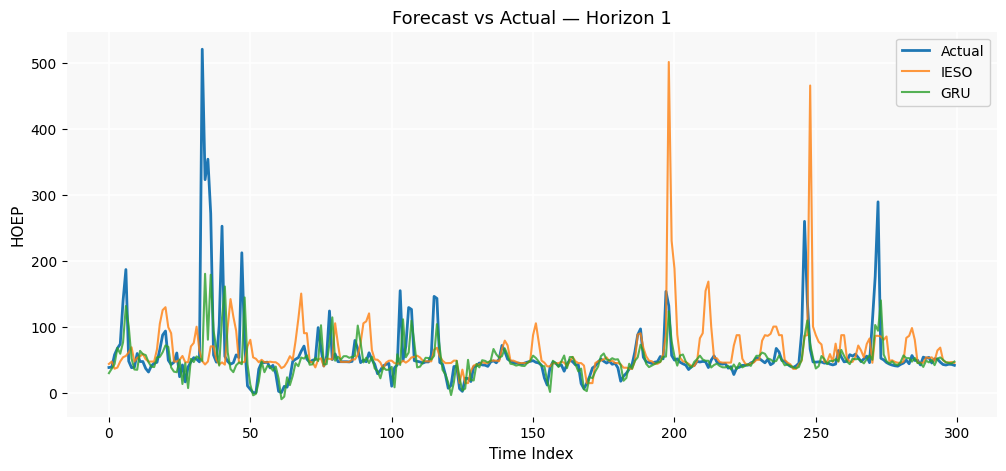

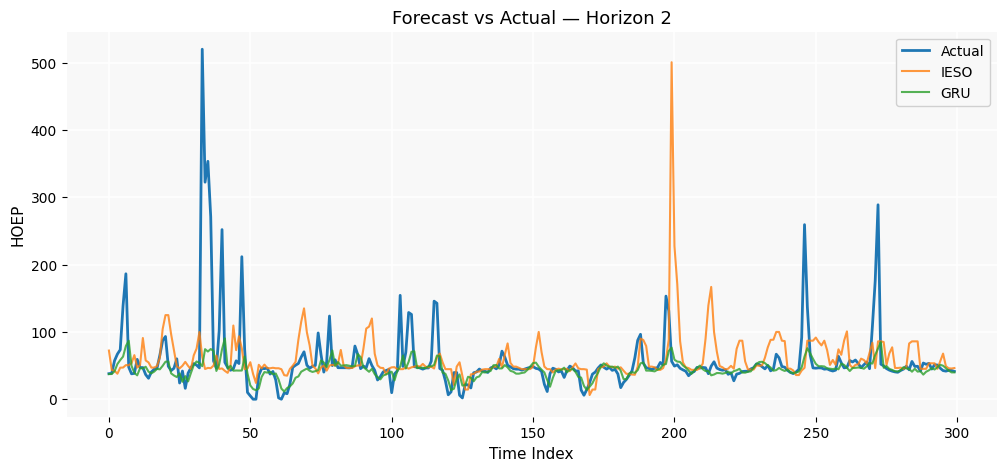

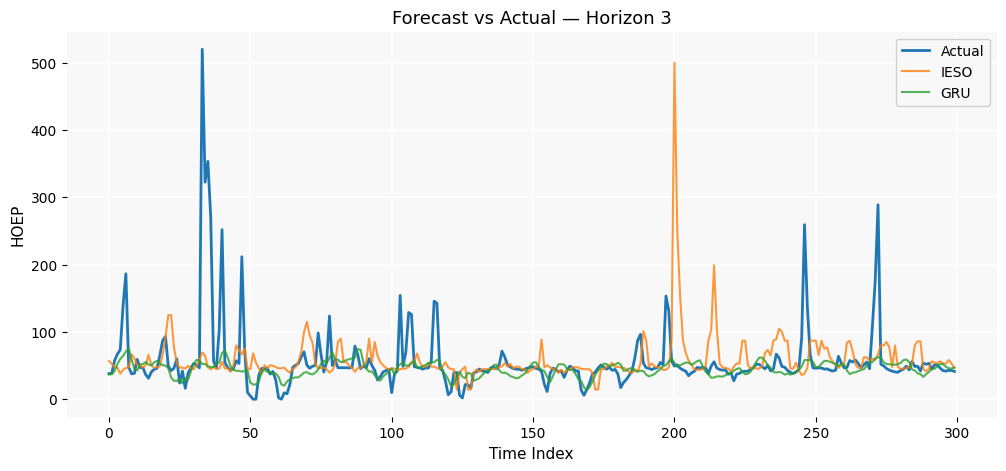

In [71]:
# Compare IESO and GRU predictions against the actual HOEP series.
# We only plot the first 300 rows to keep the visualization readable.
for h in [1,2,3]:
    # Build the set of model outputs to overlay for the current forecast horizon.
    preds_dict = {
        "IESO": master_test_df[f"pred_h{h}"].values,
        "GRU" : gru_preds[h]
    }

    # Plot actual values plus both forecast sources for side-by-side visual inspection.
    plot_predictions(master_test_df["hoep"], preds_dict , horizon=h, start_idx=0, end_idx=300)


## Visualize models performance comparison analysis

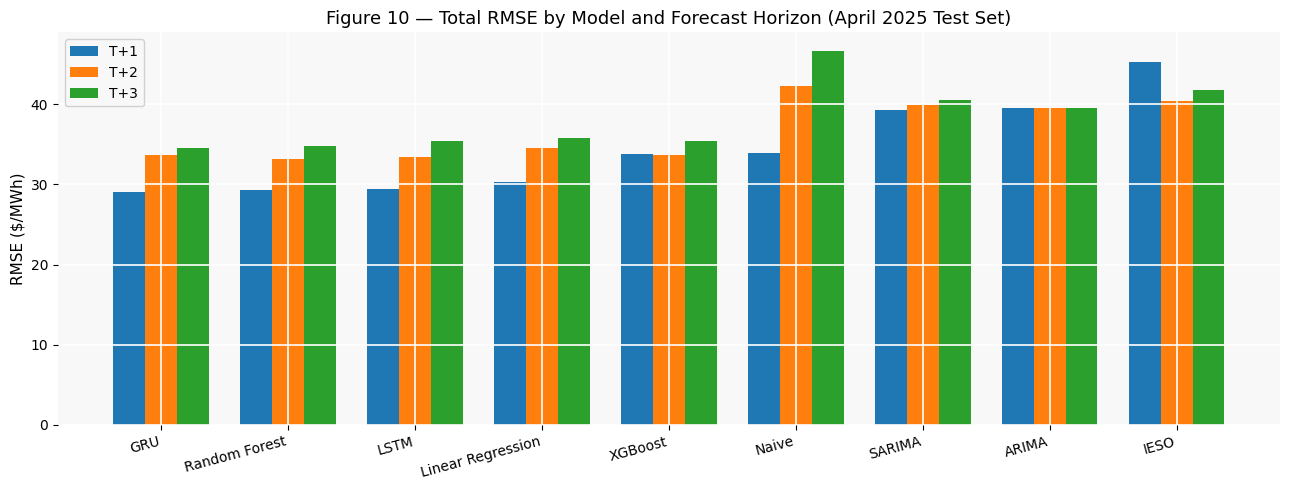

In [72]:

models = ["GRU", "Random Forest", "LSTM", "Linear Regression",
          "XGBoost", "Naive", "SARIMA", "ARIMA", "IESO"]

rmse_t1 = [29.05, 29.34, 29.41, 30.26, 33.83, 33.98, 39.24, 39.54, 45.25]
rmse_t2 = [33.63, 33.14, 33.49, 34.53, 33.74, 42.35, 39.96, 39.56, 40.46]
rmse_t3 = [34.56, 34.84, 35.44, 35.79, 35.48, 46.66, 40.59, 39.58, 41.83]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(13, 5))

plt.bar(x - width, rmse_t1, width, label="T+1")
plt.bar(x,         rmse_t2, width, label="T+2")
plt.bar(x + width, rmse_t3, width, label="T+3")

plt.xticks(x, models, rotation=15, ha="right")
plt.ylabel("RMSE ($/MWh)")
plt.title("Figure 10 — Total RMSE by Model and Forecast Horizon (April 2025 Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure_10.png", dpi=150, bbox_inches="tight")
plt.show()

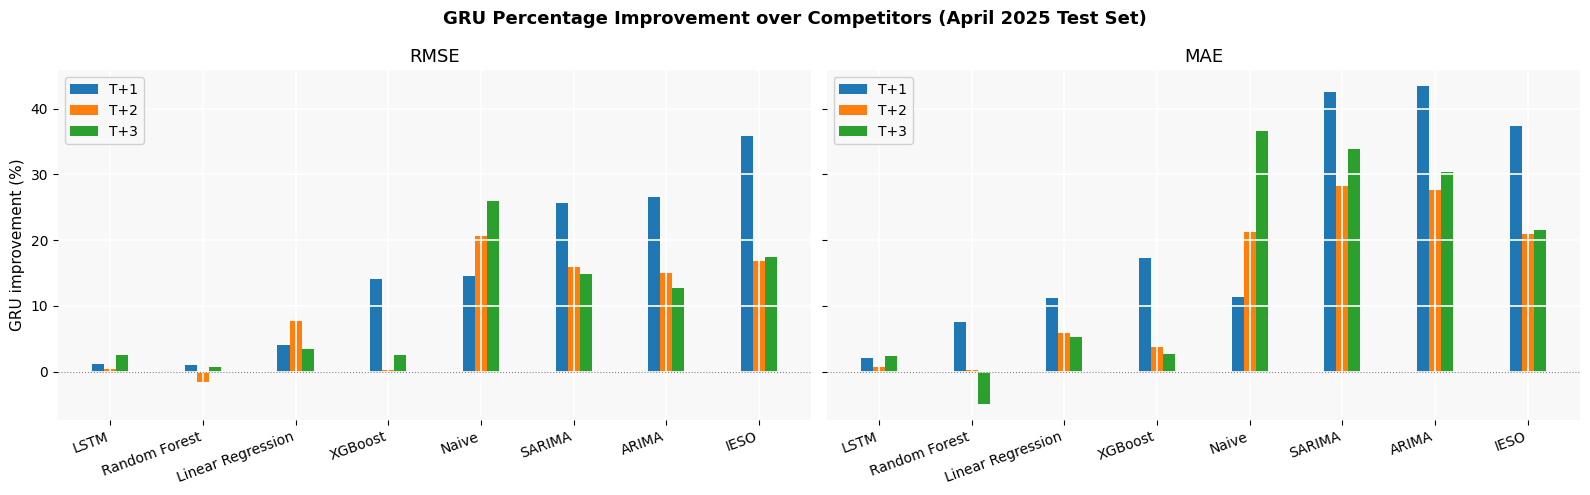

In [74]:
models = ["LSTM", "Random Forest", "Linear Regression", "XGBoost", "Naive", "SARIMA", "ARIMA", "IESO"]

# GRU % improvement over each model (positive = GRU better)
rmse_t1 = [1.2,  1.0,  4.1,  14.1, 14.6, 25.7, 26.6, 35.8]
rmse_t2 = [0.4, -1.5,  7.7,   0.3, 20.7, 15.9, 15.0, 16.9]
rmse_t3 = [2.5,  0.8,  3.5,   2.6, 25.9, 14.9, 12.7, 17.4]

mae_t1  = [2.1,  7.6, 11.2,  17.3, 11.3, 42.5, 43.4, 37.4]
mae_t2  = [0.7,  0.2,  5.9,   3.7, 21.2, 28.2, 27.7, 21.0]
mae_t3  = [2.4, -4.9,  5.3,   2.7, 36.6, 33.9, 30.4, 21.5]

x = np.arange(len(models))
width = 0.13

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# ── RMSE plot ──
axes[0].bar(x - width, rmse_t1, width, label="T+1")
axes[0].bar(x,         rmse_t2, width, label="T+2")
axes[0].bar(x + width, rmse_t3, width, label="T+3")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha="right")
axes[0].set_ylabel("GRU improvement (%)")
axes[0].set_title("RMSE")
axes[0].legend()

# ── MAE plot ──
axes[1].bar(x - width, mae_t1, width, label="T+1")
axes[1].bar(x,         mae_t2, width, label="T+2")
axes[1].bar(x + width, mae_t3, width, label="T+3")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha="right")
axes[1].set_title("MAE")
axes[1].legend()

fig.suptitle("GRU Percentage Improvement over Competitors (April 2025 Test Set)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figure_11.png", dpi=150, bbox_inches="tight")
plt.show()